# Day 3 EDA

Day 3 focuses on exploratory data analysis using the processed files created in Day 2. The notebook starts by checking whether the analytical base is clean enough to use, then moves into simple descriptive profiling, careful comparison, and later interpretation.

This notebook assumes the Day 2 pipeline has already been run and the processed files are available in `data/processed`.


## 00_setup

Analytical flow for Day 3:
1. load the Day 2 processed files
2. run analytical QA before making graphs
3. build a simple descriptive profile of the clean base
4. move into careful comparison and interpretation only after the base is confirmed usable

In [1]:
# Required packages — run this once in your terminal if needed:
#   pip install pandas matplotlib seaborn

from pathlib import Path
import pandas as pd
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    import matplotlib
    matplotlib.use("Agg")  # fallback only when not running in Jupyter
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Find the project root — works whether you run from the project root or notebooks/
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

processed_dir = project_root / "data" / "processed"
figures_dir = project_root / "figures" / "day3"
monthly_macro_file = processed_dir / "day2_merged_monthly_macro.csv"
income_file = processed_dir / "day2_income_decile_clean.csv"
figures_dir.mkdir(parents=True, exist_ok=True)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

# Readable labels used in chart titles and axis labels
LABELS = {
    "inflation_rate": "Inflation Rate",
    "house_price_index": "House Price Index",
    "unemployment_rate": "Unemployment Rate",
    "bank_rate": "Bank Rate",
    "income_value": "Income Value",
}

def label_for(column_name):
    """Return a readable label for a column name."""
    return LABELS.get(column_name, column_name)

def format_date_range(series):
    """Return a string like '2021-01 to 2025-01' from a datetime Series."""
    return f"{series.min().strftime('%Y-%m')} to {series.max().strftime('%Y-%m')}"

def export_figure(filename):
    """Save the current figure to the figures/day3 folder."""
    output_path = figures_dir / filename
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print("Saved:", output_path)

print("Figures folder:", figures_dir)
print("Monthly macro file:", monthly_macro_file)
print("Income file:", income_file)


Figures folder: /Users/hongmiaozhu/PycharmProjects/Project /figures/day3
Monthly macro file: /Users/hongmiaozhu/PycharmProjects/Project /data/processed/day2_merged_monthly_macro.csv
Income file: /Users/hongmiaozhu/PycharmProjects/Project /data/processed/day2_income_decile_clean.csv


## 01_load_and_qa

In [2]:
# Load the two processed files saved by Day 2
monthly_macro = pd.read_csv(monthly_macro_file)
income = pd.read_csv(income_file)

# Convert year_month to proper dates so pandas can sort and filter them
monthly_macro["year_month"] = pd.to_datetime(monthly_macro["year_month"], format="%Y-%m")
income["year_month"] = pd.to_datetime(income["year_month"], format="%Y-%m")

# ── Quick look ────────────────────────────────────────────────────────────
print("Monthly macro shape:", monthly_macro.shape)
print("Income shape:", income.shape)

print("\nMonthly macro — first rows:")
display(monthly_macro.head())

print("\nIncome — first rows:")
display(income.head())

# ── Missing values ────────────────────────────────────────────────────────
print("\nMissing values in monthly macro:")
print(monthly_macro.isna().sum())

print("\nMissing values in income:")
print(income.isna().sum())

# ── Structural checks ─────────────────────────────────────────────────────
# assert stops the notebook immediately with a clear message if something is wrong.
# These problems should be fixed in main.py, not patched here.
monthly_duplicates = monthly_macro.duplicated(subset=["year_month"]).sum()
income_duplicates = income.duplicated(subset=["year_month", "decile"]).sum()

assert monthly_duplicates == 0, \
    f"{monthly_duplicates} duplicate months found in macro data — fix in main.py"
assert income_duplicates == 0, \
    f"{income_duplicates} duplicate rows found in income data — fix in main.py"
assert list(income["income_frequency"].dropna().unique()) == ["annual"], \
    "Income data is not annual-only — check the source file"

print("\nDate range — monthly macro:", format_date_range(monthly_macro["year_month"]))
print("Date range — income:", format_date_range(income["year_month"]))
print("\nAll checks passed. The Day 2 data is ready for analysis.")


Monthly macro shape: (59, 7)
Income shape: (50, 7)

Monthly macro — first rows:


,year_month,inflation_rate,house_price_index,bank_rate,unemployment_rate,geo_name,source_note
0,2021-03-01,1.00,89.10,0.10,4.80,UK,Merged monthly macro dataset from official ONS...
1,2021-04-01,1.60,87.80,0.10,4.80,UK,Merged monthly macro dataset from official ONS...
2,2021-05-01,2.10,88.30,0.10,4.70,UK,Merged monthly macro dataset from official ONS...
3,2021-06-01,2.40,93.00,0.10,4.60,UK,Merged monthly macro dataset from official ONS...
4,2021-07-01,2.10,88.70,0.10,4.50,UK,Merged monthly macro dataset from official ONS...



Income — first rows:


,decile,income_value,year_month,income_frequency,geo_name,source_note,income_expanded_flag
0,1,"10,000.00",2020-03-01,annual,UK,Equivalised disposable income by decile; nomin...,False
1,2,"17,132.00",2020-03-01,annual,UK,Equivalised disposable income by decile; nomin...,False
2,3,"21,375.00",2020-03-01,annual,UK,Equivalised disposable income by decile; nomin...,False
3,4,"24,981.00",2020-03-01,annual,UK,Equivalised disposable income by decile; nomin...,False
4,5,"28,813.00",2020-03-01,annual,UK,Equivalised disposable income by decile; nomin...,False



Missing values in monthly macro:
year_month           0
inflation_rate       0
house_price_index    0
bank_rate            0
unemployment_rate    1
geo_name             0
source_note          0
dtype: int64

Missing values in income:
decile                  0
income_value            0
year_month              0
income_frequency        0
geo_name                0
source_note             0
income_expanded_flag    0
dtype: int64

Date range — monthly macro: 2021-03 to 2026-01
Date range — income: 2020-03 to 2024-03

All checks passed. The Day 2 data is ready for analysis.


In [3]:
# ── Gross outlier check ──────────────────────────────────────────────────────
# Flag any value more than 3 standard deviations from its column mean.
# This is a quick sanity check only — we are not removing any data points.
print("=== Gross Outlier Check (\u00b13\u03c3) ===\n")

macro_numeric = monthly_macro[["inflation_rate", "house_price_index", "unemployment_rate", "bank_rate"]]
outlier_flags = []

for col in macro_numeric.columns:
    mean_val = macro_numeric[col].mean()
    std_val  = macro_numeric[col].std()
    lower    = mean_val - 3 * std_val
    upper    = mean_val + 3 * std_val

    # Select rows where the column value falls outside the ±3σ band
    outliers = monthly_macro[
        (macro_numeric[col] < lower) | (macro_numeric[col] > upper)
    ][["year_month", col]]

    if len(outliers) > 0:
        outlier_flags.append(
            f"  \u26a0 {col}: {len(outliers)} value(s) outside \u00b13\u03c3 "
            f"[{lower:.2f}, {upper:.2f}]"
        )
        for _, row in outliers.iterrows():
            outlier_flags.append(f"      {row['year_month'].strftime('%Y-%m')}: {row[col]:.2f}")
    else:
        print(f"  \u2713 {col}: all values within \u00b13\u03c3 [{lower:.2f}, {upper:.2f}]")

if outlier_flags:
    for flag in outlier_flags:
        print(flag)
    print("\nNote: flagged values are not removed \u2014 they reflect real economic events.")
    print("(e.g., inflation peaking during the 2022 shock). Review before modelling.")
else:
    print("\nNo gross outliers detected in any macro variable.")

# Income sanity check — flag any value that is negative or implausibly large
income_issues = income[
    (income["income_value"] < 0) | (income["income_value"] > 500_000)
]
if len(income_issues) > 0:
    print(f"\n\u26a0 Income: {len(income_issues)} implausible value(s) found")
    display(income_issues)
else:
    print("\u2713 Income: all values in plausible range (\u00a30\u2013\u00a3500,000)")


=== Gross Outlier Check (±3σ) ===

  ✓ inflation_rate: all values within ±3σ [-2.07, 12.05]
  ✓ house_price_index: all values within ±3σ [86.28, 111.11]
  ✓ unemployment_rate: all values within ±3σ [3.06, 5.50]
  ✓ bank_rate: all values within ±3σ [-2.71, 9.22]

No gross outliers detected in any macro variable.
✓ Income: all values in plausible range (£0–£500,000)


**Outlier note:** Any values flagged above reflect real economic events (e.g., CPIH peaking near 9.6% during the 2022 energy shock), not data errors. They are retained in the analysis because removing genuine observations would bias the distributional findings. This check confirms the data is free of recording errors or implausible entries.

The QA block suggests that the Day 2 base is analytically usable for Day 3. The monthly macro file has the expected structure, unique monthly keys, and a clear shared monthly window, while the income file remains annual and decile-based.

There is one expected missing unemployment value in the latest month of the merged macro file, but this does not block analysis. The main caution is that income should still be treated as an annual comparison table rather than as a true monthly series, and `income_expanded_flag` remains `False`, confirming that no artificial monthly expansion was applied.

## 02_descriptive_profile

### A. Monthly Macro Summary

In [4]:
monthly_macro_aligned = monthly_macro[[
    "year_month", "inflation_rate", "house_price_index", "unemployment_rate", "bank_rate"
]].sort_values("year_month").reset_index(drop=True)

macro_summary_table = monthly_macro_aligned[[
    "inflation_rate", "house_price_index", "unemployment_rate", "bank_rate"
]].agg(["count", "mean", "std", "min", "median", "max"]).T

print("Table 1. Monthly macro summary statistics")
display(macro_summary_table)


Table 1. Monthly macro summary statistics


,count,mean,std,min,median,max
inflation_rate,59.00,4.99,2.35,1.00,4.10,9.60
house_price_index,59.00,98.69,4.14,87.80,99.70,104.30
unemployment_rate,58.00,4.28,0.41,3.60,4.25,5.20
bank_rate,59.00,3.26,1.99,0.10,4.00,5.25


Table 1 summarizes the main monthly macro variables over the shared analysis window. These variables are on different scales, so this table is for basic statistical profile rather than direct trend comparison.

The summary should help identify which variables vary more across the period and whether the values look broadly reasonable before interpretation.

### B. Income-by-Decile Summary

In [5]:
income_aligned = income[["year_month", "decile", "income_value"]].sort_values([
    "year_month", "decile"
]).reset_index(drop=True)

income_by_decile_summary = (
    income_aligned.groupby("decile")["income_value"]
    .agg(["mean", "min", "max"])
    .reset_index()
    .rename(columns={"mean": "mean_income", "min": "min_income", "max": "max_income"})
)

income_by_year_summary = (
    income_aligned.groupby("year_month", as_index=False)["income_value"]
    .mean()
    .rename(columns={"income_value": "mean_income_all_deciles"})
)

print("Table 2. Income summary by decile")
display(income_by_decile_summary)

print("\nTable 3. Average income across deciles by annual period")
display(income_by_year_summary)


Table 2. Income summary by decile


,decile,mean_income,min_income,max_income
0,1,"10,050.20","9,164.00","10,792.00"
1,2,"18,105.40","17,132.00","19,647.00"
2,3,"22,711.40","21,375.00","25,009.00"
3,4,"26,789.00","24,981.00","29,627.00"
4,5,"30,983.20","28,813.00","34,244.00"
5,6,"35,560.00","33,257.00","39,270.00"
6,7,"40,929.20","38,295.00","44,887.00"
7,8,"47,735.60","44,682.00","52,196.00"
8,9,"58,134.80","54,432.00","63,025.00"
9,10,"105,405.20","101,294.00","109,511.00"



Table 3. Average income across deciles by annual period


,year_month,mean_income_all_deciles
0,2020-03-01,"37,569.00"
1,2021-03-01,"37,622.10"
2,2022-03-01,"39,415.10"
3,2023-03-01,"40,912.30"
4,2024-03-01,"42,683.50"


Table 2 summarizes annual income values by decile, while Table 3 shows the average income level across annual periods. Income should rise across deciles if the structure is internally consistent.

This dataset remains annual and should not be interpreted as monthly income.

### C. Simple Distributions

#### Figure 1. Monthly Macro Variable Distributions


Saved: /Users/hongmiaozhu/PycharmProjects/Project /figures/day3/figure_01_macro_distributions.png


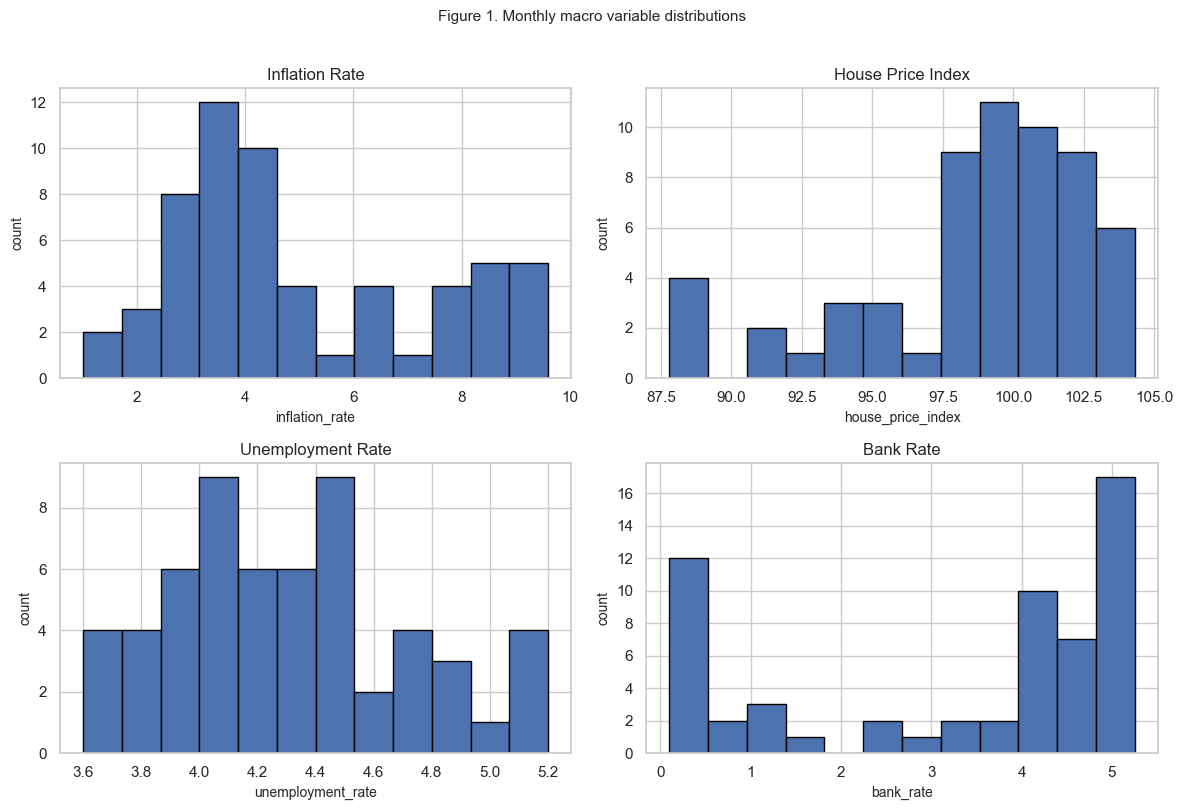

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
# ravel() flattens the 2×2 grid of axes into a plain list so we can loop over them with zip()
axes = axes.ravel()

macro_columns = ["inflation_rate", "house_price_index", "unemployment_rate", "bank_rate"]
for ax, column in zip(axes, macro_columns):
    ax.hist(monthly_macro_aligned[column].dropna(), bins=12, edgecolor="black")
    ax.set_title(label_for(column))
    ax.set_xlabel(column)
    ax.set_ylabel("count")

plt.suptitle("Figure 1. Monthly macro variable distributions", y=1.01, fontsize=11)
plt.tight_layout()
export_figure("figure_01_macro_distributions.png")
plt.show()
plt.close("all")


#### Figure 2. Mean Annual Income By Decile


Saved: /Users/hongmiaozhu/PycharmProjects/Project /figures/day3/figure_02_income_by_decile_bar.png


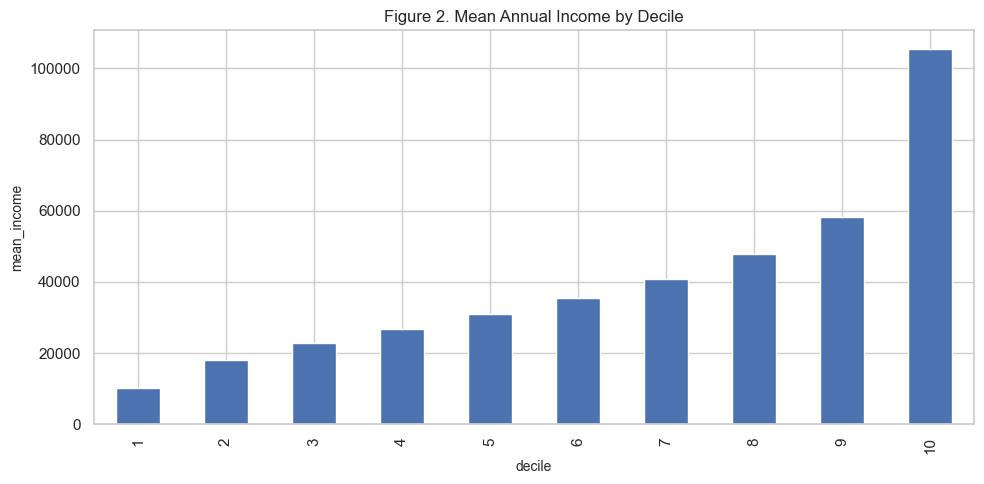

In [7]:
ax = income_by_decile_summary.plot(
    x="decile",
    y="mean_income",
    kind="bar",
    legend=False,
    title="Figure 2. Mean Annual Income by Decile"
)
ax.set_xlabel("decile")
ax.set_ylabel("mean_income")
plt.tight_layout()
export_figure("figure_02_income_by_decile_bar.png")
plt.show()
plt.close("all")


Figure 1 shows simple distributions of the monthly macro variables, and Figure 2 shows mean annual income by decile. These are descriptive checks only: they show spread, shape, and ordering, but not causal relationships.

A clear upward decile pattern supports the internal consistency of the income dataset.

### D. Aligned and Indexed Series

In [8]:
indexed_macro = monthly_macro_aligned.copy()

# Divide every value by the first value and multiply by 100 so all series start at 100.
# This lets you compare variables measured in different units on the same chart.
for column in ["inflation_rate", "house_price_index", "unemployment_rate", "bank_rate"]:
    first_value = indexed_macro[column].iloc[0]
    indexed_macro[f"{column}_index100"] = (indexed_macro[column] / first_value) * 100

print("Table 4. Aligned monthly macro series preview")
display(monthly_macro_aligned.head())

print("\nTable 5. Aligned annual income-by-decile series preview")
display(income_aligned.head())

print("\nTable 6. Indexed monthly macro series preview")
display(indexed_macro.head())


Table 4. Aligned monthly macro series preview


,year_month,inflation_rate,house_price_index,unemployment_rate,bank_rate
0,2021-03-01,1.00,89.10,4.80,0.10
1,2021-04-01,1.60,87.80,4.80,0.10
2,2021-05-01,2.10,88.30,4.70,0.10
3,2021-06-01,2.40,93.00,4.60,0.10
4,2021-07-01,2.10,88.70,4.50,0.10



Table 5. Aligned annual income-by-decile series preview


,year_month,decile,income_value
0,2020-03-01,1,"10,000.00"
1,2020-03-01,2,"17,132.00"
2,2020-03-01,3,"21,375.00"
3,2020-03-01,4,"24,981.00"
4,2020-03-01,5,"28,813.00"



Table 6. Indexed monthly macro series preview


,year_month,inflation_rate,house_price_index,unemployment_rate,bank_rate,inflation_rate_index100,house_price_index_index100,unemployment_rate_index100,bank_rate_index100
0,2021-03-01,1.00,89.10,4.80,0.10,100.00,100.00,100.00,100.00
1,2021-04-01,1.60,87.80,4.80,0.10,160.00,98.54,100.00,100.00
2,2021-05-01,2.10,88.30,4.70,0.10,210.00,99.10,97.92,100.00
3,2021-06-01,2.40,93.00,4.60,0.10,240.00,104.38,95.83,100.00
4,2021-07-01,2.10,88.70,4.50,0.10,210.00,99.55,93.75,100.00


The aligned monthly macro table keeps one row per month, while the aligned income table keeps annual rows by decile. The indexed macro table sets the first monthly observation to 100 so that later trend comparisons can be made across variables with different units.

Indexed values are useful for comparison of movement over time, but original values are still needed for interpretation.

The descriptive profile suggests that the cleaned base is suitable for exploratory analysis. The monthly macro data shows usable variation across the main indicators, the income data shows a clear decile gradient, and the aligned/indexed series are ready for later comparison.

## 03_income_vs_housing

This comparison is limited and should be treated carefully. Income is annual, while housing is monthly, so a direct month-by-month comparison would not be honest.

Income is also used here in nominal terms, because this notebook does not yet deflate the income series. That means the comparison should be read as a simple indexed trend comparison rather than a real affordability measure.

To keep the comparison transparent, housing is first aggregated to annual averages and then compared only across the overlapping years shared by both datasets. The figure below is an indexed exploratory comparison, not a direct affordability measure.

Overlapping years for annual comparison: [2021, 2022, 2023, 2024]
Table 7. Indexed HPI and income by year (shared overlap years)


,house_price_index_index100,income_decile_1_index100,income_decile_5_index100,income_decile_10_index100
2021,100.00,100.00,100.00,100.00
2022,108.58,104.43,102.56,108.11
2023,108.88,117.77,109.82,103.95
2024,109.56,117.03,116.45,106.82



Table 8. Growth from first overlap year (index points):


,series,change_since_first_overlap_year
0,house_price_index_index100,9.56
1,income_decile_1_index100,17.03
2,income_decile_5_index100,16.45
3,income_decile_10_index100,6.82


Saved: /Users/hongmiaozhu/PycharmProjects/Project /figures/day3/figure_03_income_vs_housing.png


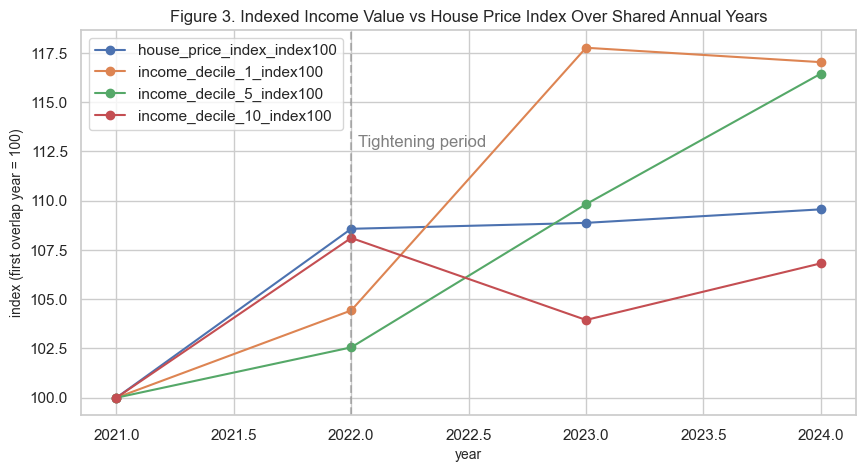

In [9]:
housing_annual = monthly_macro.copy()
housing_annual["year"] = housing_annual["year_month"].dt.year
housing_annual = (
    housing_annual.groupby("year", as_index=False)["house_price_index"]
    .mean()
)

income_annual = income.copy()
income_annual["year"] = income_annual["year_month"].dt.year

overlap_years = sorted(set(housing_annual["year"]) & set(income_annual["year"]))
print("Overlapping years for annual comparison:", overlap_years)

comparison_deciles = [1, 5, 10]
income_overlap = income_annual[
    income_annual["year"].isin(overlap_years) & income_annual["decile"].isin(comparison_deciles)
].copy()

# pivot() reshapes the table: years become rows, each decile becomes its own column.
income_wide = income_overlap.pivot(index="year", columns="decile", values="income_value").sort_index()
housing_overlap = housing_annual[housing_annual["year"].isin(overlap_years)].set_index("year").sort_index()

comparison_indexed = pd.DataFrame(index=sorted(overlap_years))
comparison_indexed["house_price_index_index100"] = (
    housing_overlap["house_price_index"] / housing_overlap["house_price_index"].iloc[0] * 100
)

for decile in comparison_deciles:
    comparison_indexed[f"income_decile_{decile}_index100"] = (
        income_wide[decile] / income_wide[decile].iloc[0] * 100
    )

growth_summary = pd.DataFrame({
    "series": comparison_indexed.columns,
    "change_since_first_overlap_year": (comparison_indexed.iloc[-1] - 100).round(2).values,
})

print("Table 7. Indexed HPI and income by year (shared overlap years)")
display(comparison_indexed)
print("\nTable 8. Growth from first overlap year (index points):")
display(growth_summary)

ax = comparison_indexed.plot(marker="o")
ax.set_title(f"Figure 3. Indexed {label_for('income_value')} vs {label_for('house_price_index')} Over Shared Annual Years")
ax.set_xlabel("year")
ax.set_ylabel("index (first overlap year = 100)")
if 2022 in comparison_indexed.index:
    ax.axvline(2022, color="gray", linestyle="--", alpha=0.5)
    ax.text(2022 + 0.03, ax.get_ylim()[1] * 0.95, "Tightening period", color="gray")
export_figure("figure_03_income_vs_housing.png")
plt.show()
plt.close("all")


This figure is only a limited exploratory comparison. It uses shared annual years and indexed values so that housing and income can be viewed on a common scale without pretending they are measured in the same units.

The income source includes a 2020 row, but this comparison uses only the shared overlap years that start at 2021. That is because the indexed comparison begins from the first shared annual year, not from the full income file.

Because income is nominal here, the chart cannot by itself show real purchasing power. It is best used to ask whether housing appears to be rising faster or slower than selected income series across the overlap period, not to claim a full affordability result.


## 04_macro_context

This section gives a simple view of the monthly macro context. It uses three stacked panels with a shared time axis: House Price Index, Inflation and Bank Rate, and Unemployment. A few vertical reference lines mark major points in the cycle so the chart stays readable. The goal is to show the broad pattern of the period without making the figure too busy.

Saved: /Users/hongmiaozhu/PycharmProjects/Project /figures/day3/figure_04_macro_context.png


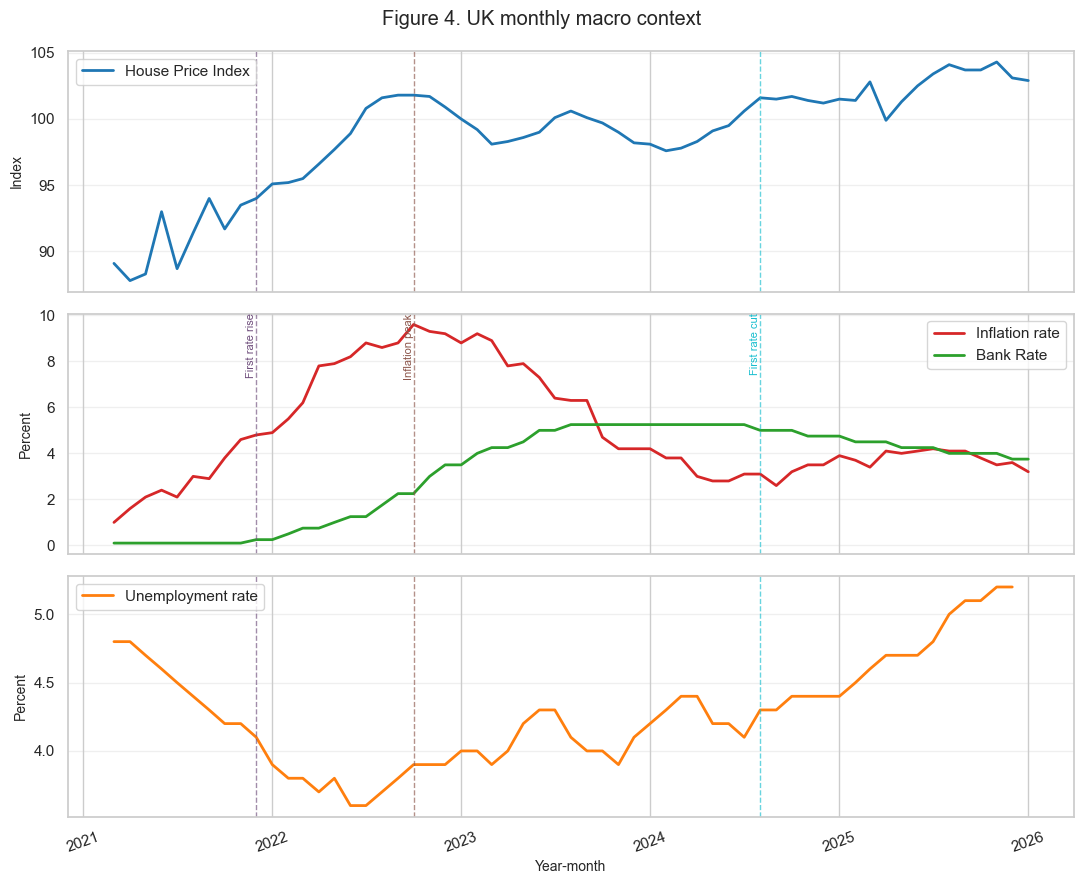

In [10]:
# Find key turning points in the monthly data for the chart reference lines.
macro_context = monthly_macro_aligned.copy()

# First rate rise: Bank Rate moved above its near-zero floor of 0.10% in late 2021.
NEAR_ZERO_BANK_RATE = 0.10
tp_first_hike = macro_context.loc[macro_context["bank_rate"] > NEAR_ZERO_BANK_RATE, "year_month"].iloc[0]

# Inflation peak: the month with the highest recorded inflation rate.
tp_inf_peak = macro_context.loc[macro_context["inflation_rate"].idxmax(), "year_month"]

# First rate cut: cummax() tracks the running maximum of Bank Rate up to each month.
# The first row where Bank Rate falls below that running maximum is the first cut.
tp_first_cut = macro_context.loc[
    macro_context["bank_rate"] < macro_context["bank_rate"].cummax(), "year_month"
].iloc[0]

turning_points = [
    (tp_first_hike, "First rate rise"),
    (tp_inf_peak, "Inflation peak"),
    (tp_first_cut, "First rate cut"),
]

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
ax0, ax1, ax2 = axes

# Use explicit colours so each trend is easy to distinguish.
series_colours = {
    "house_price_index": "#1f77b4",  # blue
    "inflation_rate": "#d62728",     # red
    "bank_rate": "#2ca02c",          # green
    "unemployment_rate": "#ff7f0e",  # orange
}
turning_point_colours = {
    "First rate rise": "#6f4e7c",
    "Inflation peak": "#8c564b",
    "First rate cut": "#17becf",
}

# Panel 1: house prices.
ax0.plot(
    macro_context["year_month"],
    macro_context["house_price_index"],
    linewidth=2,
    color=series_colours["house_price_index"],
    label="House Price Index",
)
ax0.set_ylabel("Index")
ax0.legend(loc="upper left")

# Panel 2: inflation and Bank Rate.
ax1.plot(
    macro_context["year_month"],
    macro_context["inflation_rate"],
    linewidth=2,
    color=series_colours["inflation_rate"],
    label="Inflation rate",
)
ax1.plot(
    macro_context["year_month"],
    macro_context["bank_rate"],
    linewidth=2,
    color=series_colours["bank_rate"],
    label="Bank Rate",
)
ax1.set_ylabel("Percent")
ax1.legend(loc="upper right")

# Panel 3: unemployment.
ax2.plot(
    macro_context["year_month"],
    macro_context["unemployment_rate"],
    linewidth=2,
    color=series_colours["unemployment_rate"],
    label="Unemployment rate",
)
ax2.set_ylabel("Percent")
ax2.set_xlabel("Year-month")
ax2.legend(loc="upper left")

# Add the same reference lines to each panel.
for ax in axes:
    ax.grid(axis="y", alpha=0.3)
    for date, label in turning_points:
        ax.axvline(
            date,
            color=turning_point_colours[label],
            linestyle="--",
            linewidth=1,
            alpha=0.65,
        )

# Put simple labels for the turning points on the middle panel only.
for date, label in turning_points:
    ax1.text(
        date,
        ax1.get_ylim()[1],
        label,
        rotation=90,
        va="top",
        ha="right",
        fontsize=8,
        color=turning_point_colours[label],
    )

plt.suptitle("Figure 4. UK monthly macro context")
plt.xticks(rotation=20)
plt.tight_layout()
export_figure("figure_04_macro_context.png")
plt.show()
plt.close("all")


The chart shows the broad macro pattern of the period without trying to do too much at once. Inflation rises sharply into 2022 and then falls back, Bank Rate increases later and then begins to fall, and unemployment stays in a relatively narrow range. House prices weaken during the tightening period and recover later.

**Cautions.** These panels use different units, so the heights are not directly comparable across panels. The reference lines are included only to help with timing. They do not prove that one variable caused movement in another.

## 05_correlations

This block gives an initial econometric reading of the monthly macro data. It first aligns the shared monthly window and keeps only continuous, comparable variables.

Pearson correlation is used as the main descriptive measure, while Spearman correlation is added as a simple sensitivity check. These results are descriptive only and do not imply causality.

In [11]:
correlation_base = monthly_macro_aligned[[
    "year_month", "inflation_rate", "house_price_index", "unemployment_rate", "bank_rate"
]].dropna().copy().sort_values("year_month").reset_index(drop=True)

# Check there are no gaps in the monthly series.
# Convert to period ordinals first — in pandas 3+, Period.diff() returns DateOffset
# objects, not integers, so comparing directly with == 1 no longer works.
# Ordinal subtraction always gives plain integers regardless of pandas version.
month_gaps = (
    correlation_base["year_month"]
    .dt.to_period("M")
    .apply(lambda p: p.ordinal)  # convert each Period to a plain integer month count
    .diff()
    .dropna()
)
assert (month_gaps == 1).all(), \
    "Gap found in the monthly data — check the source files"

correlation_variables = [
    "inflation_rate", "house_price_index", "unemployment_rate", "bank_rate"
]

print("Table 9. Aligned monthly correlation base (preview)")
display(correlation_base.head())
print("Correlation base shape:", correlation_base.shape)
print("Date range:", format_date_range(correlation_base["year_month"]))

pearson_corr = correlation_base[correlation_variables].corr(method="pearson")
spearman_corr = correlation_base[correlation_variables].corr(method="spearman")

print("\nTable 10. Pearson correlation matrix")
display(pearson_corr.round(2))

print("\nTable 11. Spearman correlation matrix")
display(spearman_corr.round(2))

# Flag variable pairs where Pearson and Spearman differ by more than 0.20.
# A large gap usually means the relationship is driven by one short episode
# rather than a consistent pattern across the whole window.
print("\nPairs with large Pearson vs Spearman gap (|diff| > 0.20):")
found_any = False
for row_var in correlation_variables:
    for col_var in correlation_variables:
        if row_var >= col_var:
            continue
        p = pearson_corr.loc[row_var, col_var]
        s = spearman_corr.loc[row_var, col_var]
        if abs(p - s) > 0.20:
            print(f"  {row_var} vs {col_var}: Pearson={p:.2f}, Spearman={s:.2f}, diff={abs(p - s):.2f}")
            found_any = True
if not found_any:
    print("  None found.")


Table 9. Aligned monthly correlation base (preview)


,year_month,inflation_rate,house_price_index,unemployment_rate,bank_rate
0,2021-03-01,1.00,89.10,4.80,0.10
1,2021-04-01,1.60,87.80,4.80,0.10
2,2021-05-01,2.10,88.30,4.70,0.10
3,2021-06-01,2.40,93.00,4.60,0.10
4,2021-07-01,2.10,88.70,4.50,0.10


Correlation base shape: (58, 5)
Date range: 2021-03 to 2025-12

Table 10. Pearson correlation matrix


,inflation_rate,house_price_index,unemployment_rate,bank_rate
inflation_rate,1.00,0.30,-0.67,-0.02
house_price_index,0.30,1.00,0.09,0.71
unemployment_rate,-0.67,0.09,1.00,0.16
bank_rate,-0.02,0.71,0.16,1.00



Table 11. Spearman correlation matrix


,inflation_rate,house_price_index,unemployment_rate,bank_rate
inflation_rate,1.00,0.17,-0.70,-0.04
house_price_index,0.17,1.00,0.22,0.39
unemployment_rate,-0.70,0.22,1.00,0.05
bank_rate,-0.04,0.39,0.05,1.00



Pairs with large Pearson vs Spearman gap (|diff| > 0.20):
  bank_rate vs house_price_index: Pearson=0.71, Spearman=0.39, diff=0.32


#### Figure 5. Pairwise Correlation Heatmap


Saved: /Users/hongmiaozhu/PycharmProjects/Project /figures/day3/figure_05_correlation_heatmap_pearson_spearman.png


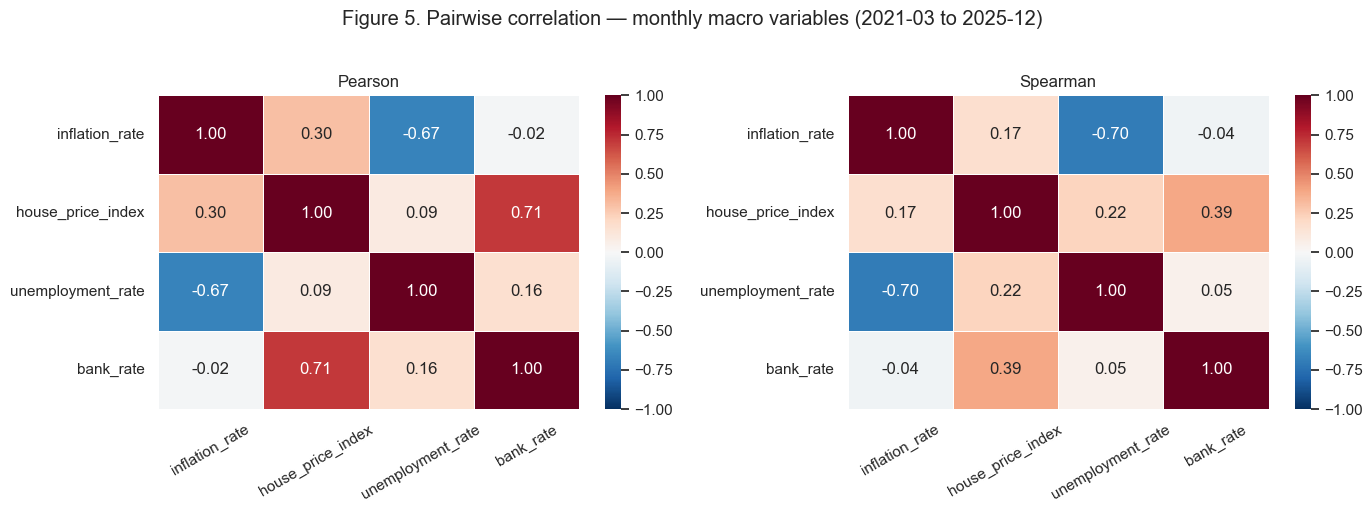

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, matrix, method in zip(axes, [pearson_corr, spearman_corr], ["Pearson", "Spearman"]):
    sns.heatmap(
        matrix.round(2),
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        center=0,
        vmin=-1,
        vmax=1,
        linewidths=0.5,
        ax=ax,
    )
    ax.set_title(method)
    ax.tick_params(axis="x", rotation=30)
    ax.tick_params(axis="y", rotation=0)
date_range = format_date_range(correlation_base["year_month"])
plt.suptitle(f"Figure 5. Pairwise correlation — monthly macro variables ({date_range})", y=1.02)
plt.tight_layout()
export_figure("figure_05_correlation_heatmap_pearson_spearman.png")
plt.show()
plt.close("all")


In [13]:
lagged_correlation_base = correlation_base.copy()
# shift(n) moves the column down by n rows, so each row now holds the value from n months earlier (a lag).
# The first n rows become NaN because there is no earlier value to shift in.
lagged_correlation_base["bank_rate_lag_1"] = lagged_correlation_base["bank_rate"].shift(1)
lagged_correlation_base["bank_rate_lag_3"] = lagged_correlation_base["bank_rate"].shift(3)
lagged_correlation_base = lagged_correlation_base.dropna().copy()

lagged_bank_rate_corr = lagged_correlation_base[[
    "inflation_rate", "house_price_index", "unemployment_rate", "bank_rate_lag_1", "bank_rate_lag_3"
]].corr(method="pearson").loc[["bank_rate_lag_1", "bank_rate_lag_3"], [
    "inflation_rate", "house_price_index", "unemployment_rate"
]]

print("Table 12. Exploratory lagged Bank Rate correlations (Pearson)")
display(lagged_bank_rate_corr.round(2))


Table 12. Exploratory lagged Bank Rate correlations (Pearson)


,inflation_rate,house_price_index,unemployment_rate
bank_rate_lag_1,-0.24,0.64,0.34
bank_rate_lag_3,-0.36,0.62,0.42


### Lagged Bank Rate \u2014 exploratory reading

Table 12 tests whether Bank Rate with a simple lag (1-month and 3-month) changes the correlation pattern with the other macro variables.

Key observations:
- **Bank Rate lag-1 vs HPI:** Pearson r\u2009=\u20090.64. This is lower than the contemporaneous correlation (r\u2009=\u20090.71), suggesting that part of the Bank Rate\u2013HPI association is driven by same-period co-movement rather than a lagged transmission effect.
- **Bank Rate lag-3 vs HPI:** Pearson r\u2009=\u20090.62. The further lag does not strengthen the relationship \u2014 the correlation weakens slightly with distance, which is consistent with the contemporaneous result being partly an artefact of both series trending upward together during the tightening episode.
- **Bank Rate lag-1 and lag-3 vs inflation:** Both show weak negative correlations (\u22120.24 and \u22120.36), consistent with the Bank of England raising rates *in response to* inflation \u2014 a policy reaction function rather than a predictive relationship.
- **Bank Rate lags vs unemployment:** Moderate positive correlations (0.34 and 0.42), consistent with tighter policy eventually being associated with higher unemployment, though the direction of causality is ambiguous in a simple correlation.

This exploratory lag analysis informed the Day 4 feature selection: `bank_rate_lag1` and `bank_rate_lag3` were included as model features because they showed non-trivial correlations with HPI and because lagged features help reduce same-period leakage. The correlations are descriptive \u2014 they do not establish that Bank Rate *causes* HPI movements.

The two strongest relationships in this window are inflation vs unemployment (r = −0.67 / ρ = −0.70) and Bank Rate vs house prices (r = +0.71 / ρ = +0.39). The inflation–unemployment pair is stable across both methods, which gives it more weight as a descriptive finding. The Bank Rate–HPI pair is not: Pearson comes in much higher than Spearman, which usually means the result is driven by the shape of a specific episode rather than a general rank-order relationship — both series rose sharply in 2021–2022 and then diverged, so the high Pearson likely reflects that episode more than a consistent pattern. All other pairs are weak or near-zero contemporaneously. This is an exploratory summary only. Correlation coefficients describe co-movement in this dataset; they do not establish causality, control for third variables, or generalise beyond the 58-month window shown.

## 06_social_pressure

### Simple pressure proxy

This section uses a simple proxy, not a direct measure of household hardship. First, annual income is adjusted using overall CPIH inflation to create an approximate real-income index. Second, annual house prices are compared with nominal income on a common base-100 scale.

The income file includes 2020, but the proxy analysis uses 2021 to 2024 only. That is because 2021 is the chosen base year and the shared comparison window for the annual proxy.

This is useful for an early read on whether lower-income groups seem to be falling behind housing costs, but it has clear limits:
- the same CPIH deflator is used for every decile
- the house price index is not the same thing as rent or mortgage payments
- only four overlapping annual periods are available

### Part A — Approximate real income by decile

Nominal annual income is adjusted using CPIH and then indexed to 2021 = 100. This gives a simple view of how purchasing power changed across deciles over the overlap years.

Proxy analysis years: [2021, 2022, 2023, 2024] (base year = 2021)
Price level index (2021 = 1.0):
  2021: 1.0000  (cumulative inflation from 2021: 0.0%)
  2022: 1.0790  (cumulative inflation from 2021: 7.9%)
  2023: 1.1527  (cumulative inflation from 2021: 15.3%)
  2024: 1.1906  (cumulative inflation from 2021: 19.1%)

Table 13. Approximate real income index by decile (2021 = 100):


decile,1,2,3,4,5,6,7,8,9,10
year,,,,,,,,,,
2021,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
2022,96.80,93.30,94.40,94.80,95.00,96.20,96.20,96.60,97.50,100.20
2023,102.20,96.50,97.20,96.00,95.30,95.00,95.50,95.60,95.40,90.20
2024,98.30,95.80,98.10,98.20,97.80,98.20,97.40,97.20,96.30,89.70


Saved: /Users/hongmiaozhu/PycharmProjects/Project /figures/day3/figure_06_social_pressure_real_income_index.png


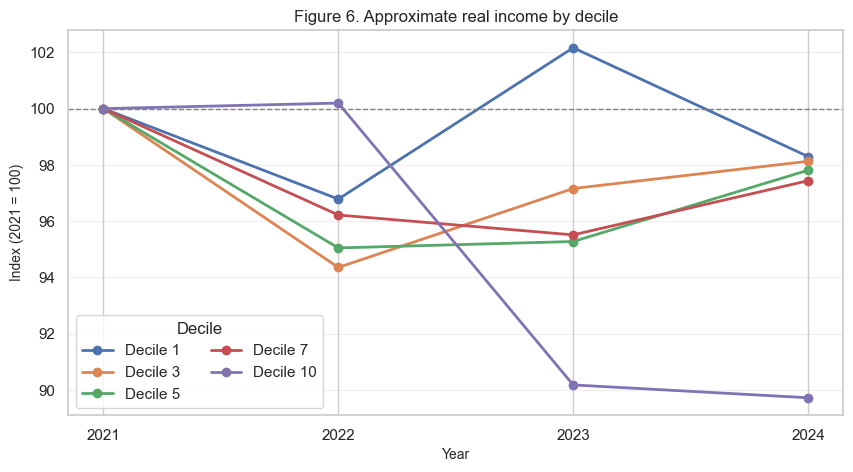

In [14]:
# Build annual average inflation from the monthly macro data.
# .assign() adds a new column; the lambda receives the DataFrame and extracts the year.
annual_inflation_base = monthly_macro_aligned.copy()
annual_inflation_base["year"] = annual_inflation_base["year_month"].dt.year
annual_inflation = annual_inflation_base.groupby("year")["inflation_rate"].mean()

# Build a simple cumulative price level with 2021 as the base year.
OVERLAP_YEARS = [2021, 2022, 2023, 2024]
base_year = 2021

print(f"Proxy analysis years: {OVERLAP_YEARS} (base year = {base_year})")

price_level = {}
level = 1.0
for year in OVERLAP_YEARS:
    if year == base_year:
        price_level[year] = 1.0
    else:
        level = level * (1 + annual_inflation.loc[year] / 100)
        price_level[year] = round(level, 4)

print("Price level index (2021 = 1.0):")
for year, value in price_level.items():
    print(f"  {year}: {value:.4f}  (cumulative inflation from 2021: {(value - 1) * 100:.1f}%)")

# Keep only the years shared by the income and macro data.
income_overlap = income_aligned[
    income_aligned["year_month"].dt.year.isin(OVERLAP_YEARS)
].copy()
income_overlap["year"] = income_overlap["year_month"].dt.year
# .map() looks up each year in the price_level dict and returns the matching cumulative index value.
income_overlap["price_level"] = income_overlap["year"].map(price_level)
income_overlap["real_income"] = income_overlap["income_value"] / income_overlap["price_level"]

# Index each decile to its own 2021 starting point.
base_income = (
    income_overlap[income_overlap["year"] == base_year]
    .set_index("decile")["real_income"]
)
# .map(base_income) looks up each row's decile in the base_income Series to get that decile's 2021 starting value.
# Dividing by it and multiplying by 100 sets every decile's 2021 value to exactly 100.
income_overlap["real_income_index"] = (
    income_overlap["real_income"] / income_overlap["decile"].map(base_income) * 100
)

real_income_summary = (
    income_overlap.pivot(index="year", columns="decile", values="real_income_index")
    .round(1)
)
print("\nTable 13. Approximate real income index by decile (2021 = 100):")
display(real_income_summary)

plot_deciles = [1, 3, 5, 7, 10]

fig, ax = plt.subplots(figsize=(10, 5))
for decile in plot_deciles:
    subset = income_overlap[income_overlap["decile"] == decile].sort_values("year")
    ax.plot(subset["year"], subset["real_income_index"], marker="o", linewidth=2, label=f"Decile {decile}")

ax.axhline(100, color="grey", linestyle="--", linewidth=1)
ax.set_title("Figure 6. Approximate real income by decile")
ax.set_xlabel("Year")
ax.set_ylabel("Index (2021 = 100)")
ax.set_xticks(OVERLAP_YEARS)
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Decile", ncol=2)

export_figure("figure_06_social_pressure_real_income_index.png")
plt.show()
plt.close("all")


### Part A2 — Inflation burden by decile


Cumulative CPIH inflation 2021–2024: 19.1%

Table. Real income change by decile (2021 to 2024, CPIH-deflated):


,decile,nominal_income_2021,nominal_income_2024,real_income_2024,real_change_pct
0,1,"9,164.00","10,725.00","9,008.00",-1.70
1,2,"17,229.00","19,647.00","16,502.00",-4.20
2,3,"21,406.00","25,009.00","21,005.00",-1.90
3,4,"25,350.00","29,627.00","24,884.00",-1.80
4,5,"29,406.00","34,244.00","28,762.00",-2.20
5,6,"33,601.00","39,270.00","32,983.00",-1.80
6,7,"38,693.00","44,887.00","37,701.00",-2.60
7,8,"45,109.00","52,196.00","43,840.00",-2.80
8,9,"54,969.00","63,025.00","52,935.00",-3.70
9,10,"101,294.00","108,205.00","90,883.00",-10.30


Saved: /Users/hongmiaozhu/PycharmProjects/Project /figures/day3/figure_06b_inflation_burden_by_decile.png


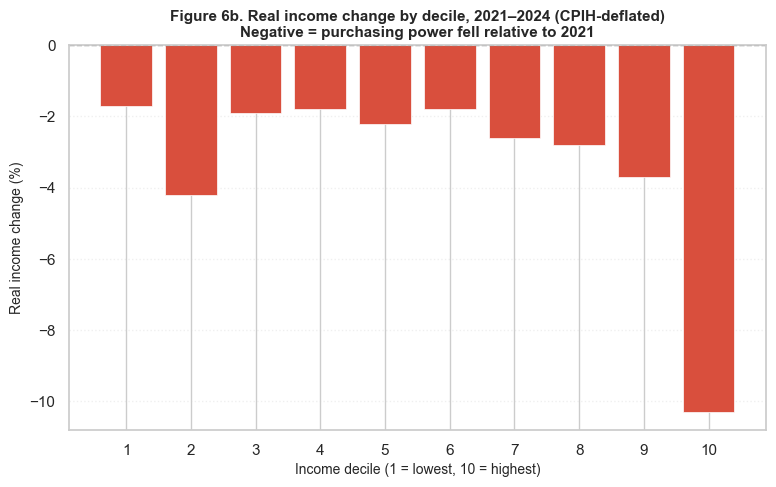

In [15]:
# ── Part A2: Inflation burden by decile ──────────────────────────────────────
# CPIH is applied as a uniform deflator — we don't have decile-specific inflation rates.
# But we can show how the same cumulative inflation erodes purchasing power differently
# across deciles, because lower-income households start from a smaller absolute income.

# Get 2021 and 2024 nominal income for each decile, indexed by decile number
inc_2021 = income_overlap[income_overlap["year"] == 2021][["decile", "income_value"]].set_index("decile")
inc_2024 = income_overlap[income_overlap["year"] == 2024][["decile", "income_value"]].set_index("decile")

# price_level[2024] is the cumulative CPIH multiplier from 2021 (e.g. 1.19 = 19% total inflation)
cumulative_inflation = price_level[2024]

# Divide 2024 nominal income by the price level to get real purchasing power in 2021 prices
real_inc_2024 = inc_2024["income_value"] / cumulative_inflation

# Real change = real 2024 income minus 2021 nominal income (both now in 2021 prices)
real_change     = real_inc_2024 - inc_2021["income_value"]
real_change_pct = (real_change / inc_2021["income_value"]) * 100

inflation_burden = pd.DataFrame({
    "decile":              range(1, 11),
    "nominal_income_2021": inc_2021["income_value"].values,
    "nominal_income_2024": inc_2024["income_value"].values,
    "real_income_2024":    real_inc_2024.values.round(0),
    "real_change_pct":     real_change_pct.values.round(1),
})

print(f"Cumulative CPIH inflation 2021\u20132024: {(cumulative_inflation - 1) * 100:.1f}%")
print("\nTable. Real income change by decile (2021 to 2024, CPIH-deflated):")
display(inflation_burden)

# Bar chart: red if real purchasing power fell, green if it rose
fig, ax = plt.subplots(figsize=(9, 5))
colours = ["#d94f3d" if v < 0 else "#3a7d44" for v in inflation_burden["real_change_pct"]]
ax.bar(inflation_burden["decile"], inflation_burden["real_change_pct"],
       color=colours, edgecolor="white", linewidth=0.5)
ax.axhline(0, color="#888888", linewidth=1.0, linestyle="--")
ax.set_title(
    "Figure 6b. Real income change by decile, 2021\u20132024 (CPIH-deflated)\n"
    "Negative = purchasing power fell relative to 2021",
    fontsize=11, fontweight="bold",
)
ax.set_xlabel("Income decile (1 = lowest, 10 = highest)")
ax.set_ylabel("Real income change (%)")
ax.set_xticks(range(1, 11))
ax.grid(axis="y", alpha=0.3, linestyle=":")
export_figure("figure_06b_inflation_burden_by_decile.png")
plt.show()
plt.close("all")


### Part A2 \u2014 Inflation burden by decile: interpretation

Figure 6b makes the H1 mechanism visible from a different angle than Figure 6. While Figure 6 shows the real income *index* (trends over time), Figure 6b shows the cumulative real income *change* from 2021 to 2024 for each decile.

Because the same CPIH deflator is applied uniformly, any variation across deciles in this chart reflects differences in nominal income growth rather than differences in the inflation rate experienced. A negative bar means that decile's nominal income did not keep pace with cumulative CPIH inflation \u2014 real purchasing power fell.

This directly links inflation to income by decile as the plan requires: not just housing costs (Part B below) but inflation itself as a pressure on purchasing power. The known limitation applies: lower-income households face higher *effective* inflation because their spending is concentrated in food, energy, and housing \u2014 the categories that drove CPI above the headline CPIH figure used here. This uniform deflator therefore *understates* the real burden on Decile 1\u20133.

### Part B — House prices versus income on a common scale

This chart keeps the comparison simple. Annual house prices and annual income are both indexed to 2021 = 100, so the lines can be compared on the same scale. The chart does not measure direct housing affordability, but it does show whether house prices seem to be rising faster than income.

Saved: /Users/hongmiaozhu/PycharmProjects/Project /figures/day3/figure_07_social_pressure_housing_vs_income.png


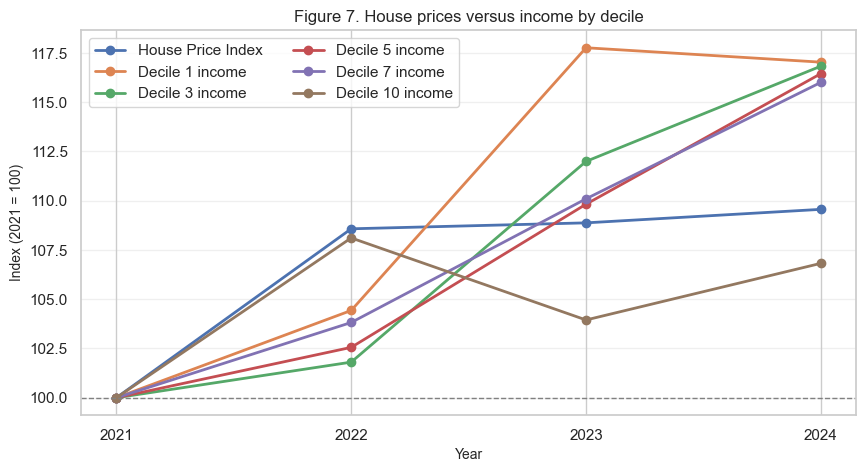

In [16]:
# Build an annual house price index for the overlap years only.
hpi_annual_base = monthly_macro_aligned.copy()
hpi_annual_base["year"] = hpi_annual_base["year_month"].dt.year
hpi_annual_filtered = hpi_annual_base[hpi_annual_base["year"].isin(OVERLAP_YEARS)]
hpi_annual = hpi_annual_filtered.groupby("year")["house_price_index"].mean()
hpi_base = hpi_annual.loc[base_year]
hpi_index = (hpi_annual / hpi_base * 100).rename("hpi_index").reset_index()

# Index nominal income to 2021 = 100 for each decile.
inc_nom = income_overlap.copy()
base_nominal_income = (
    inc_nom[inc_nom["year"] == base_year]
    .set_index("decile")["income_value"]
)
inc_nom["nom_income_index"] = (
    inc_nom["income_value"] / inc_nom["decile"].map(base_nominal_income) * 100
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hpi_index["year"], hpi_index["hpi_index"], marker="o", linewidth=2, label="House Price Index")

for decile in plot_deciles:
    subset = inc_nom[inc_nom["decile"] == decile].sort_values("year")
    ax.plot(subset["year"], subset["nom_income_index"], marker="o", linewidth=2, label=f"Decile {decile} income")

ax.axhline(100, color="grey", linestyle="--", linewidth=1)
ax.set_title("Figure 7. House prices versus income by decile")
ax.set_xlabel("Year")
ax.set_ylabel("Index (2021 = 100)")
ax.set_xticks(OVERLAP_YEARS)
ax.grid(axis="y", alpha=0.3)
ax.legend(ncol=2)

export_figure("figure_07_social_pressure_housing_vs_income.png")
plt.show()
plt.close("all")


### Part C — Decile pressure snapshot

Parts A and B showed trends over time. This chart collapses the comparison to a single snapshot: for each decile, it shows how far house price growth exceeded that decile's nominal income growth between 2021 and 2024. A taller bar means stronger housing pressure relative to income for that group.

This chart does not assume a clean 1-to-10 ordering. It is simply a snapshot of how the nominal housing-versus-income gap looks by decile at the end of the overlap period.

Table 14. Decile pressure snapshot (2021 to 2024)
(HPI growth minus nominal income growth in index points; higher = more housing pressure)


,decile,income_index_2024,housing_pressure_gap_index_pts
0,1,117.03,-7.50
1,2,114.03,-4.50
2,3,116.83,-7.30
3,4,116.87,-7.30
4,5,116.45,-6.90
5,6,116.87,-7.30
6,7,116.01,-6.40
7,8,115.71,-6.10
8,9,114.66,-5.10
9,10,106.82,2.70


Saved: /Users/hongmiaozhu/PycharmProjects/Project /figures/day3/figure_08_decile_pressure_proxy_bar.png


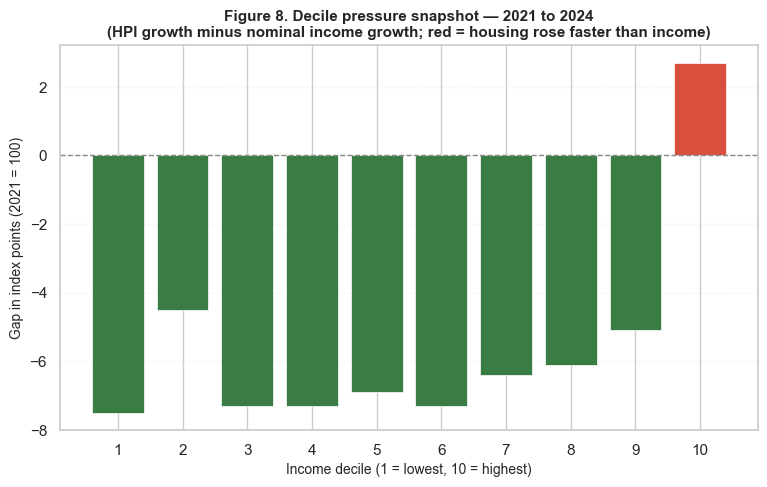

In [17]:
# Snapshot comparison: how far HPI growth exceeded each decile's income growth by end_year
end_year = OVERLAP_YEARS[-1]
hpi_end = hpi_index.loc[hpi_index["year"] == end_year, "hpi_index"].values[0]

# Get all 10 deciles' nominal income index at end_year
pressure_table = (
    inc_nom[inc_nom["year"] == end_year][["decile", "nom_income_index"]]
    .sort_values("decile")
    .reset_index(drop=True)
)
# Pressure gap = how many index points housing grew above that decile's income
pressure_table["housing_pressure_gap"] = (hpi_end - pressure_table["nom_income_index"]).round(1)

print(f"Table 14. Decile pressure snapshot ({base_year} to {end_year})")
print("(HPI growth minus nominal income growth in index points; higher = more housing pressure)")
display(pressure_table.rename(columns={
    "nom_income_index": f"income_index_{end_year}",
    "housing_pressure_gap": "housing_pressure_gap_index_pts",
}))

fig, ax = plt.subplots(figsize=(9, 5))
# Colour bars red where housing rose faster than income, green where income kept up
# List comprehension: for each gap value, pick red if housing grew faster than income, green otherwise.
bar_colors = ["#d94f3d" if v > 0 else "#3a7d44" for v in pressure_table["housing_pressure_gap"]]
ax.bar(
    pressure_table["decile"],
    pressure_table["housing_pressure_gap"],
    color=bar_colors,
    edgecolor="white",
    linewidth=0.5,
)
ax.axhline(0, color="#888888", linewidth=1.0, linestyle="--")
ax.set_title(
    f"Figure 8. Decile pressure snapshot \u2014 {base_year} to {end_year}\n"
    "(HPI growth minus nominal income growth; red = housing rose faster than income)",
    fontsize=11, fontweight="bold",
)
ax.set_xlabel("Income decile (1 = lowest, 10 = highest)")
ax.set_ylabel("Gap in index points (2021 = 100)")
ax.set_xticks(pressure_table["decile"])
ax.grid(axis="y", alpha=0.3, linestyle=":")
export_figure("figure_08_decile_pressure_proxy_bar.png")
plt.show()
plt.close("all")


### Interpretation

Parts A and B show trends over time: real income fell during the 2022 inflation shock and house prices rose faster than nominal income across some parts of the period. Part C (Figure 8) adds a cross-sectional snapshot: in nominal terms, income outpaced house-price growth for most deciles between 2021 and 2024, while decile 10 is the clearest case where house-price growth remained above income growth. This does not mean affordability improved for lower deciles, because (a) housing costs through rent and mortgage interest are not captured by the price index, and (b) cumulative CPIH inflation over 2021 to 2024 still eroded real income across deciles (see Part A).

The more careful read is that decile 10 looks distinctly different from the rest, while deciles 1 to 9 are relatively flat in this nominal gap measure. So this chart does not show a clear monotonic 1-to-10 ordering of pressure, and it should not be used as strong evidence of a simple ranked decile gradient on its own.

All three parts are proxy-based and exploratory. Main limits:
- the same CPIH deflator is applied to every decile
- the house price index measures asset prices, not rent or mortgage costs
- only four overlapping annual periods are available


## 07_key_findings

- Tightening cycle and housing response. Inflation peaked in late 2022 and Bank Rate peaked in 2023. House prices weakened during the tightening period and only moved back to new highs after the first rate cut in 2024. Unemployment stayed relatively stable, with only a mild increase toward the end of the window.
- Most reliable macro relationship. The strongest and most stable result is the negative relationship between inflation and unemployment, which remains similar in both Pearson and Spearman results. By contrast, the Bank Rate-house price relationship is much less stable and should be treated cautiously.
- Income and housing pattern by decile. Real income fell across deciles during the inflation shock. The proxy analysis suggests affordability pressure remained significant, but the house-price-versus-income gap does not show a clear monotonic decile gradient and should be treated as exploratory.
- Main limitation. The social-pressure analysis relies on proxies. CPIH is applied uniformly across deciles, and the house price index is only an indirect measure of housing cost pressure. This means the results show likely exposure, not a directly measured cost burden.
- Implication for Day 4. The clearest candidates to carry forward are the inflation-unemployment relationship and the income-housing pressure pattern by decile. Both are useful, but the second should remain clearly labelled as proxy-based.

## 08_day4_handoff

Candidate variables for Day 4:

* The monthly macro variables (inflation rate, house price index, unemployment rate, and Bank Rate) are the strongest candidates for Day 4 because they are clean, continuous, and available across the full monthly window. The income-by-decile series should be used more carefully: it is annual and only overlaps with the macro data for a few years, so it is better for group comparison than for time-series modelling.

Relationships worth carrying forward:

* The strongest relationship in the current data is the negative association between inflation and unemployment, which appears stable across methods. The real income pattern by decile is also useful and suggests that lower deciles are more exposed to inflation pressure. The income–housing gap can be kept as an early proxy for affordability pressure, but it should still be treated as exploratory.

Limitations to carry forward:

* There are three main limits. First, the income data is annual and decile-level only. Second, the CPIH deflator is applied equally across all deciles, so the real income comparison is only approximate. Third, the analysis window covers one recent tightening cycle, so the results should not be generalized too broadly.

What should not be treated as definitive:

* The Bank Rate–house price relationship should be treated carefully, because the Pearson and Spearman results suggest it may be driven by a specific short-run episode rather than a stable pattern. The social pressure result is also only a proxy. It suggests that lower deciles may be more exposed, but it does not directly measure household cost burdens.